In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path('../log/cache.csv')
df = pd.read_csv(csv_path)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.sort_values('iteration').reset_index(drop=True)

fitness_col = 'avg_fitness'
fitness_cols = [
    col for col in df.columns
    if col.endswith('_fitness') and col != fitness_col
]

numeric_cols = [
    fitness_col,
    *fitness_cols,
    'iteration',
    'populationSize',
    'generations',
    'newChromosomes',
    'mutator_child2_weight',
    'mutator_child2_p',
    'mutator_child2_numMutations',
    'mutator_child1_weight',
    'mutator_child1_p',
    'mutator_child1_numMutations',
    'general_MAX_CLUSTER_DISTANCE',
    'general_MAX_CLUSTER_JOIN_DISTANCE',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()


,iteration,timestamp,avg_fitness,general_MAX_CLUSTER_DISTANCE,general_MAX_CLUSTER_JOIN_DISTANCE,populationSize,generations,newChromosomes,eliminator_type,eliminator_elitism,...,crossover_child4_k,crossover_child4_p,crossover_child4_weight,crossover_child5_k,crossover_child5_p,crossover_child5_weight,selection_type,selection_tournamentSize,48xxx_random_constraints.job_fitness,51000_rijeka_random_constraints.job_fitness
0,1,2026-06-17 15:24:09.817278,64.624848,5.511144,15.099063,5000,2000,20,EliteEliminator,8,...,6,0.319196,0.615276,5,0.525631,0.350627,TournamentSelection,3,101.568046,27.681649
1,2,2026-06-17 15:34:18.902397,59.756477,10.211272,17.899675,200,8000,26,EliteEliminator,4,...,4,0.671720,0.252349,3,0.567840,0.545844,TournamentSelection,2,94.178730,25.334223
2,3,2026-06-17 15:35:04.985979,60.450161,5.893158,18.537005,50,2000,6,EliteEliminator,4,...,4,0.676526,0.727664,6,0.565126,0.538343,TournamentSelection,4,94.568332,26.331989
3,4,2026-06-17 16:07:27.943578,61.124880,9.074308,18.908655,50,500,24,EliteEliminator,10,...,7,0.364541,0.414391,7,0.826165,0.110284,TournamentSelection,5,96.339489,25.910270
4,5,2026-06-17 16:15:22.501249,62.837381,7.787873,15.956559,200,8000,18,EliteGeometricEliminator,13,...,2,0.686399,0.396045,7,0.247864,0.807092,TournamentSelection,3,99.389062,26.285700


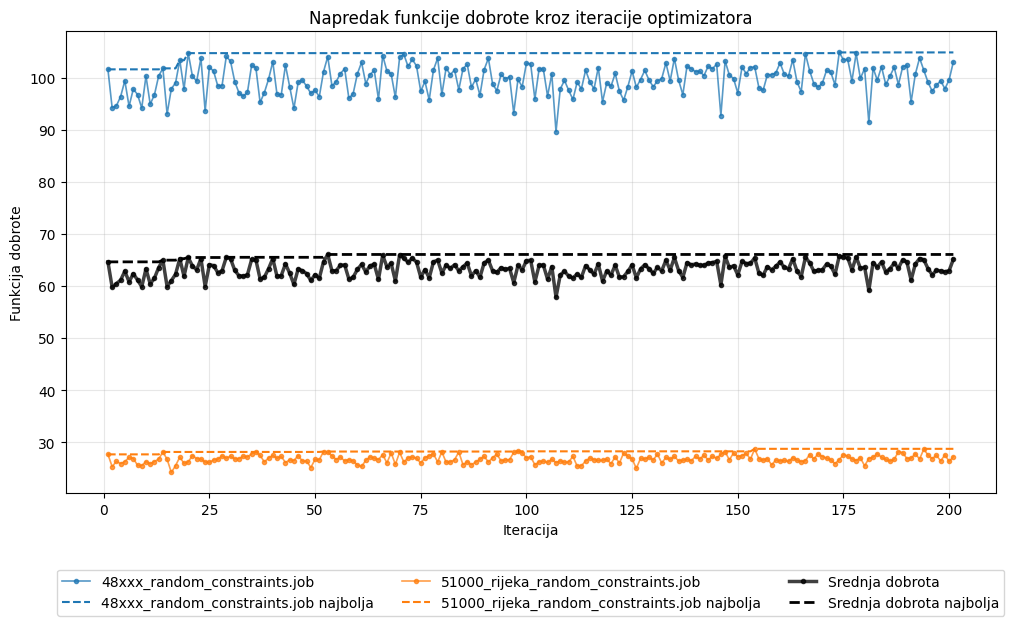

In [38]:
plt.figure(figsize=(12, 6))

fitness_plot_cols = [*fitness_cols, fitness_col]
fitness_labels = {
    fitness_col: 'Srednja dobrota',
    **{col: col.replace('_fitness', '') for col in fitness_cols},
}

for col in fitness_plot_cols:
    label = fitness_labels[col]
    is_average = col == fitness_col
    line = plt.plot(
        df['iteration'],
        df[col],
        marker='o',
        markersize=3,
        linewidth=2.5 if is_average else 1.2,
        alpha=0.75,
        color='black' if is_average else None,
        label=label,
    )[0]
    plt.plot(
        df['iteration'],
        df[col].cummax(),
        linestyle='--',
        linewidth=2.0 if is_average else 1.5,
        color=line.get_color(),
        label=f'{label} najbolja',
    )

plt.xlabel('Iteracija')
plt.ylabel('Funkcija dobrote')
plt.title('Napredak funkcije dobrote kroz iteracije optimizatora')
# Legend outside the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.grid(True, alpha=0.3)
plt.show()


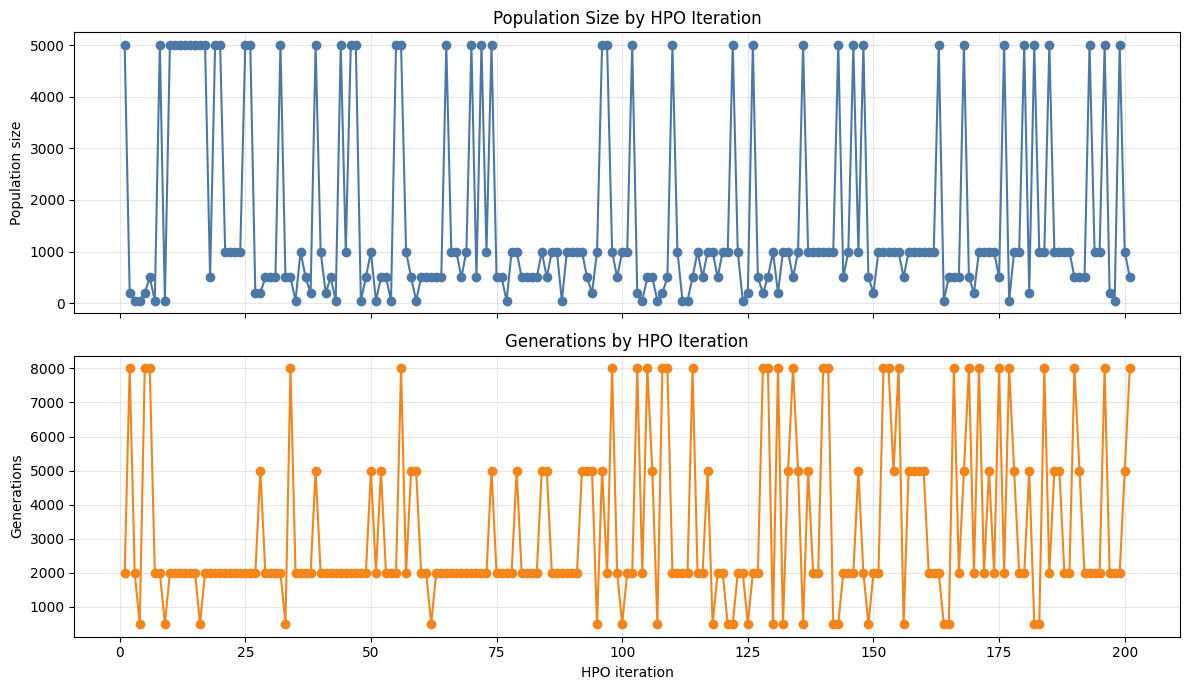

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df['iteration'], df['populationSize'], marker='o', linewidth=1.5, color='#4C78A8')
axes[0].set_ylabel('Population size')
axes[0].set_title('Population Size by HPO Iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['iteration'], df['generations'], marker='o', linewidth=1.5, color='#F58518')
axes[1].set_xlabel('HPO iteration')
axes[1].set_ylabel('Generations')
axes[1].set_title('Generations by HPO Iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


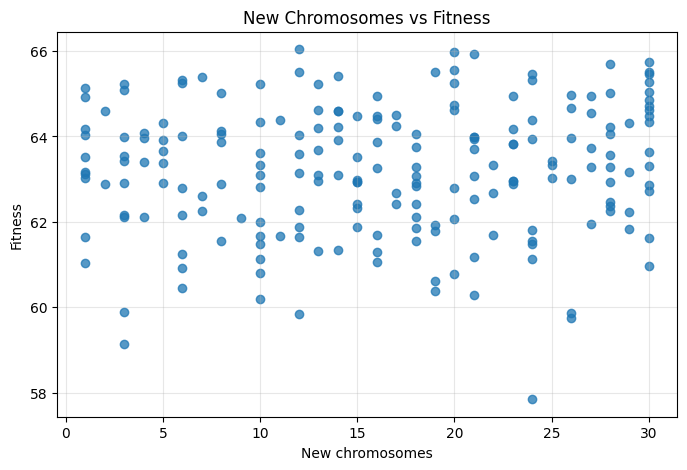

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df['newChromosomes'], df[fitness_col], alpha=0.75)
plt.xlabel('New chromosomes')
plt.ylabel('Fitness')
plt.title('New Chromosomes vs Fitness')
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\2082958612.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(selection_data, labels=selection_order)


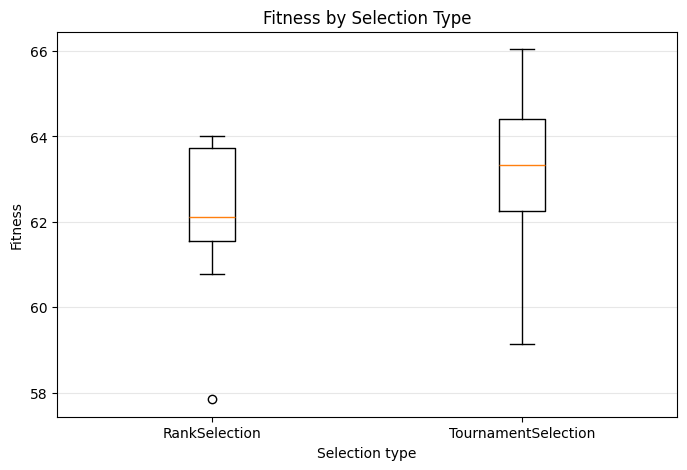

In [40]:
selection_order = sorted(df['selection_type'].dropna().unique())
selection_data = [
    df.loc[df['selection_type'] == selection_type, fitness_col].dropna()
    for selection_type in selection_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(selection_data, labels=selection_order)
plt.xlabel('Selection type')
plt.ylabel('Fitness')
plt.title('Fitness by Selection Type')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\206297776.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(eliminator_data, labels=eliminator_order)


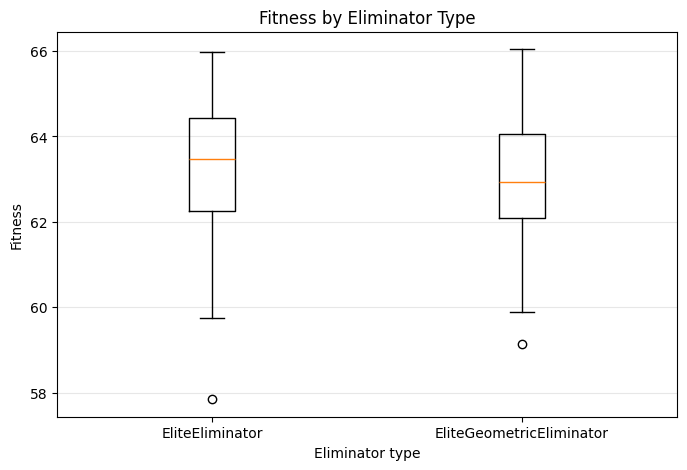

In [27]:
eliminator_order = sorted(df['eliminator_type'].dropna().unique())
eliminator_data = [
    df.loc[df['eliminator_type'] == eliminator_type, fitness_col].dropna()
    for eliminator_type in eliminator_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(eliminator_data, labels=eliminator_order)
plt.xlabel('Eliminator type')
plt.ylabel('Fitness')
plt.title('Fitness by Eliminator Type')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


In [ ]:
elite_eliminator_df = df[df['eliminator_type'] == 'EliteEliminator'].dropna(
    subset=['eliminator_elitism', fitness_col]
).copy()

if elite_eliminator_df.empty:
    print('No EliteEliminator rows available for elitism analysis.')
else:
    elite_eliminator_df['eliminator_elitism'] = elite_eliminator_df['eliminator_elitism'].astype(int)
    elitism_order = sorted(elite_eliminator_df['eliminator_elitism'].unique())
    elitism_data = [
        elite_eliminator_df.loc[
            elite_eliminator_df['eliminator_elitism'] == elitism,
            fitness_col,
        ].dropna()
        for elitism in elitism_order
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(
        elite_eliminator_df['eliminator_elitism'],
        elite_eliminator_df[fitness_col],
        alpha=0.75,
        color='#4C78A8',
    )
    axes[0].set_xlabel('Elitism')
    axes[0].set_ylabel('Fitness')
    axes[0].set_title('EliteEliminator: Elitism vs Fitness')
    axes[0].grid(True, alpha=0.3)

    axes[1].boxplot(elitism_data, tick_labels=elitism_order)
    axes[1].set_xlabel('Elitism')
    axes[1].set_ylabel('Fitness')
    axes[1].set_title('EliteEliminator: Fitness by Elitism')
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


,fitness_weighted_mean_weight,mean_weight,fitness_weighted_share
Geometric column crossover,0.223467,0.223472,0.223467
Geometric row crossover,0.221731,0.221632,0.221731
K-switch crossover,0.193906,0.193800,0.193906
Column K-switch crossover,0.183246,0.183216,0.183246
Single-point crossover,0.177650,0.177880,0.177650


C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\3508511329.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([weight_df[col].dropna() for col in weight_df.columns], labels=weight_df.columns)


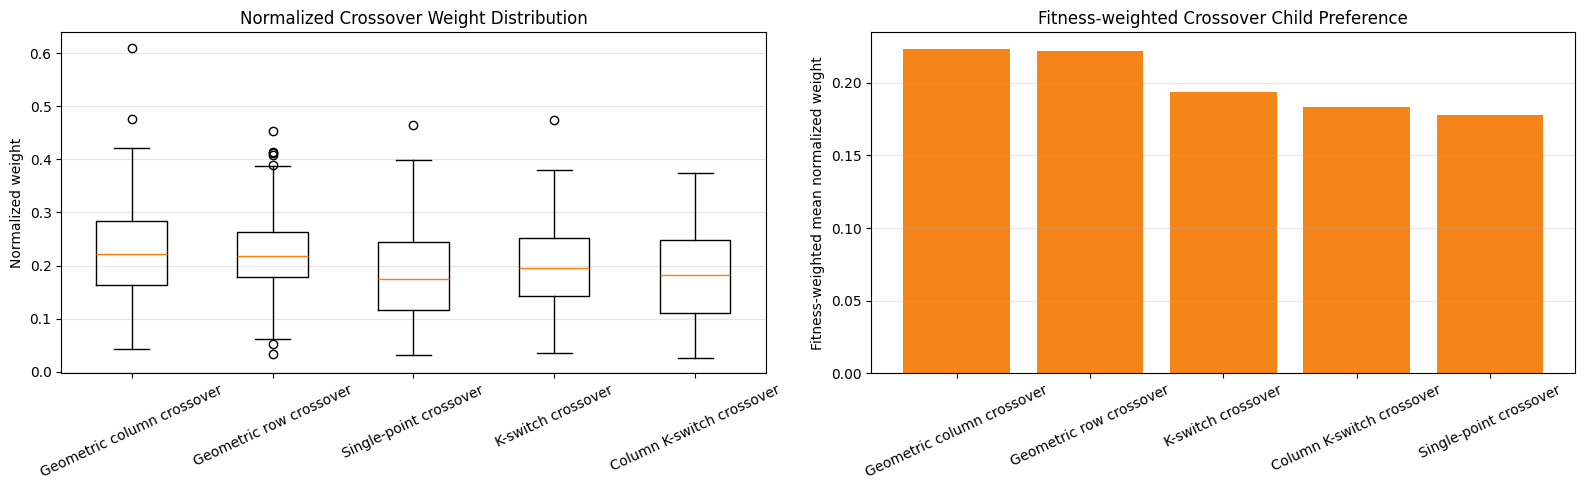

In [28]:
fitness = df[fitness_col]
total_fitness = fitness.sum()

child_weight_cols = {
    'crossover_child1_weight': 'Geometric column crossover',
    'crossover_child2_weight': 'Geometric row crossover',
    'crossover_child3_weight': 'Single-point crossover',
    'crossover_child4_weight': 'K-switch crossover',
    'crossover_child5_weight': 'Column K-switch crossover',
}

weight_cols = list(child_weight_cols)
weight_sum = df[weight_cols].sum(axis=1).replace(0, pd.NA)
normalized_weight_df = df[weight_cols].div(weight_sum, axis=0)
weight_df = normalized_weight_df.rename(columns=child_weight_cols)
summary = pd.DataFrame(
    {
        'fitness_weighted_mean_weight': {
            label: (normalized_weight_df[col] * fitness).sum() / total_fitness
            for col, label in child_weight_cols.items()
        },
        'mean_weight': {
            label: normalized_weight_df[col].mean()
            for col, label in child_weight_cols.items()
        },
    }
).sort_values('fitness_weighted_mean_weight', ascending=False)
summary['fitness_weighted_share'] = summary['fitness_weighted_mean_weight'] / summary['fitness_weighted_mean_weight'].sum()

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].boxplot([weight_df[col].dropna() for col in weight_df.columns], labels=weight_df.columns)
axes[0].set_ylabel('Normalized weight')
axes[0].set_title('Normalized Crossover Weight Distribution')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(summary.index, summary['fitness_weighted_mean_weight'], color='#F58518')
axes[1].set_ylabel('Fitness-weighted mean normalized weight')
axes[1].set_title('Fitness-weighted Crossover Child Preference')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


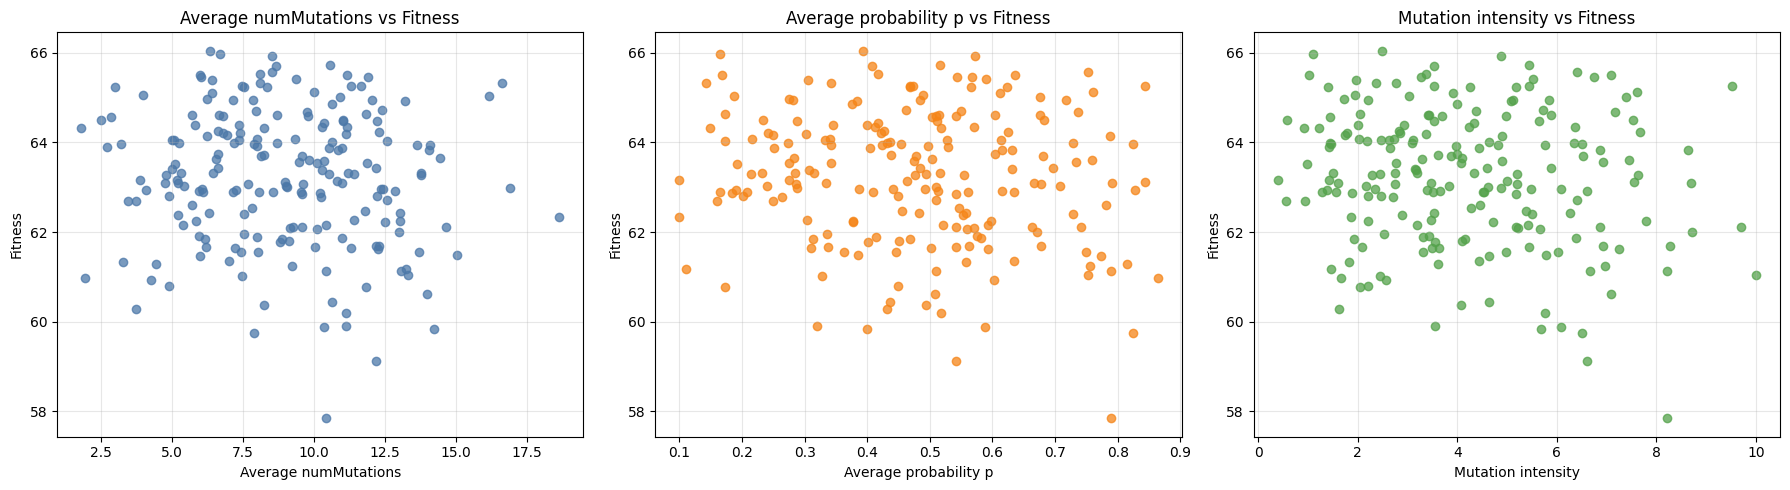

In [29]:
mutator_children = [
    {
        'label': 'Random simple mutator 1',
        'num_mutations': 'mutator_child1_numMutations',
        'probability': 'mutator_child1_p',
        'weight': 'mutator_child1_weight',
    },
    {
        'label': 'Random simple mutator 2',
        'num_mutations': 'mutator_child2_numMutations',
        'probability': 'mutator_child2_p',
        'weight': 'mutator_child2_weight',
    },
]

weight_cols = [child['weight'] for child in mutator_children]
weight_sum = df[weight_cols].sum(axis=1).replace(0, pd.NA)
normalized_weights = {
    child['weight']: df[child['weight']] / weight_sum
    for child in mutator_children
}

mutator_analysis = pd.DataFrame(
    {
        'average_num_mutations': sum(
            df[child['num_mutations']] * normalized_weights[child['weight']]
            for child in mutator_children
        ),
        'average_probability': sum(
            df[child['probability']] * normalized_weights[child['weight']]
            for child in mutator_children
        ),
        fitness_col: df[fitness_col],
    }
).dropna()
mutator_analysis['mutation_intensity'] = (
    mutator_analysis['average_num_mutations']
    * mutator_analysis['average_probability']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plots = [
    ('average_num_mutations', 'Average numMutations', '#4C78A8'),
    ('average_probability', 'Average probability p', '#F58518'),
    ('mutation_intensity', 'Mutation intensity', '#54A24B'),
]

for ax, (column, xlabel, color) in zip(axes, plots):
    ax.scatter(mutator_analysis[column], mutator_analysis[fitness_col], alpha=0.75, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Fitness')
    ax.set_title(f'{xlabel} vs Fitness')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\387424402.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(tournament_data, labels=tournament_order)


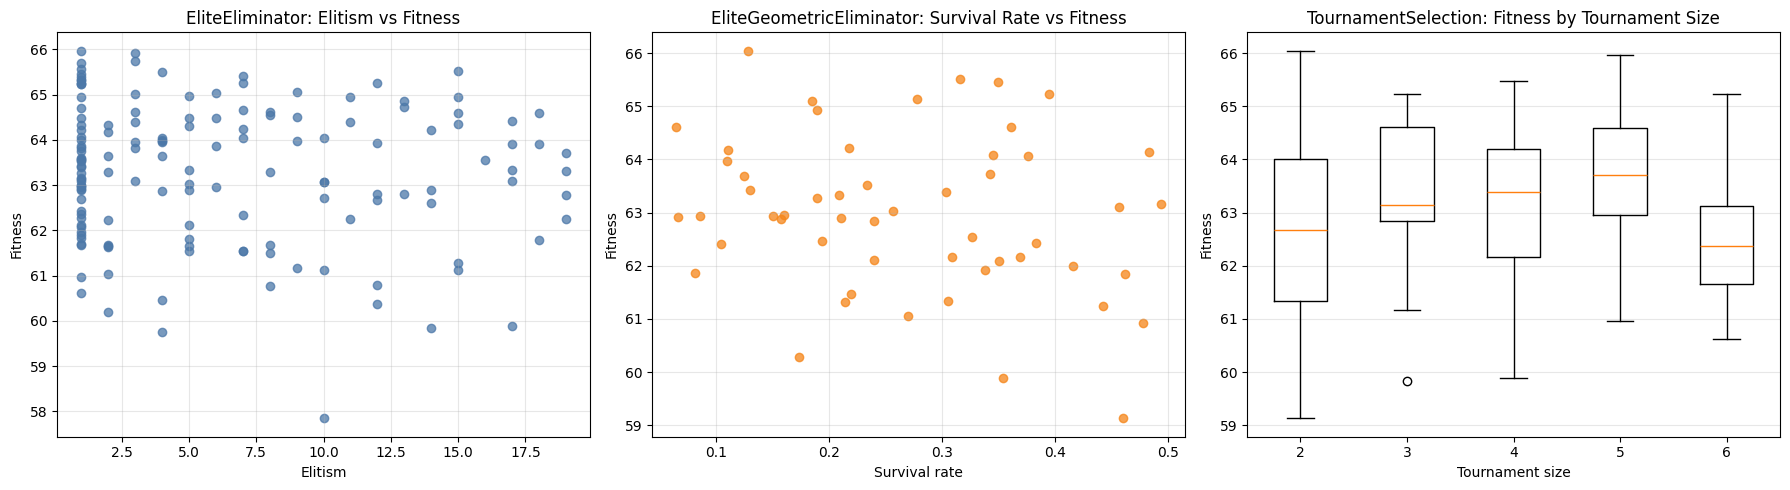

In [30]:
elite_df = df[df['eliminator_type'] == 'EliteEliminator'].dropna(subset=['eliminator_elitism', fitness_col])
geo_elite_df = df[df['eliminator_type'] == 'EliteGeometricEliminator'].dropna(subset=['eliminator_survivalRate', fitness_col])
tournament_df = df[df['selection_type'] == 'TournamentSelection'].dropna(subset=['selection_tournamentSize', fitness_col]).copy()
tournament_df['selection_tournamentSize'] = tournament_df['selection_tournamentSize'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(elite_df['eliminator_elitism'], elite_df[fitness_col], alpha=0.75, color='#4C78A8')
axes[0].set_xlabel('Elitism')
axes[0].set_ylabel('Fitness')
axes[0].set_title('EliteEliminator: Elitism vs Fitness')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(geo_elite_df['eliminator_survivalRate'], geo_elite_df[fitness_col], alpha=0.75, color='#F58518')
axes[1].set_xlabel('Survival rate')
axes[1].set_ylabel('Fitness')
axes[1].set_title('EliteGeometricEliminator: Survival Rate vs Fitness')
axes[1].grid(True, alpha=0.3)

tournament_order = sorted(tournament_df['selection_tournamentSize'].unique())
tournament_data = [
    tournament_df.loc[tournament_df['selection_tournamentSize'] == size, fitness_col]
    for size in tournament_order
]
axes[2].boxplot(tournament_data, labels=tournament_order)
axes[2].set_xlabel('Tournament size')
axes[2].set_ylabel('Fitness')
axes[2].set_title('TournamentSelection: Fitness by Tournament Size')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\1786094598.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order)
C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\1786094598.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order)
C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\1786094598.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order)
C:\Users\stjep\AppData\Local\Temp\ipykernel_19140\1786094598.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; sup

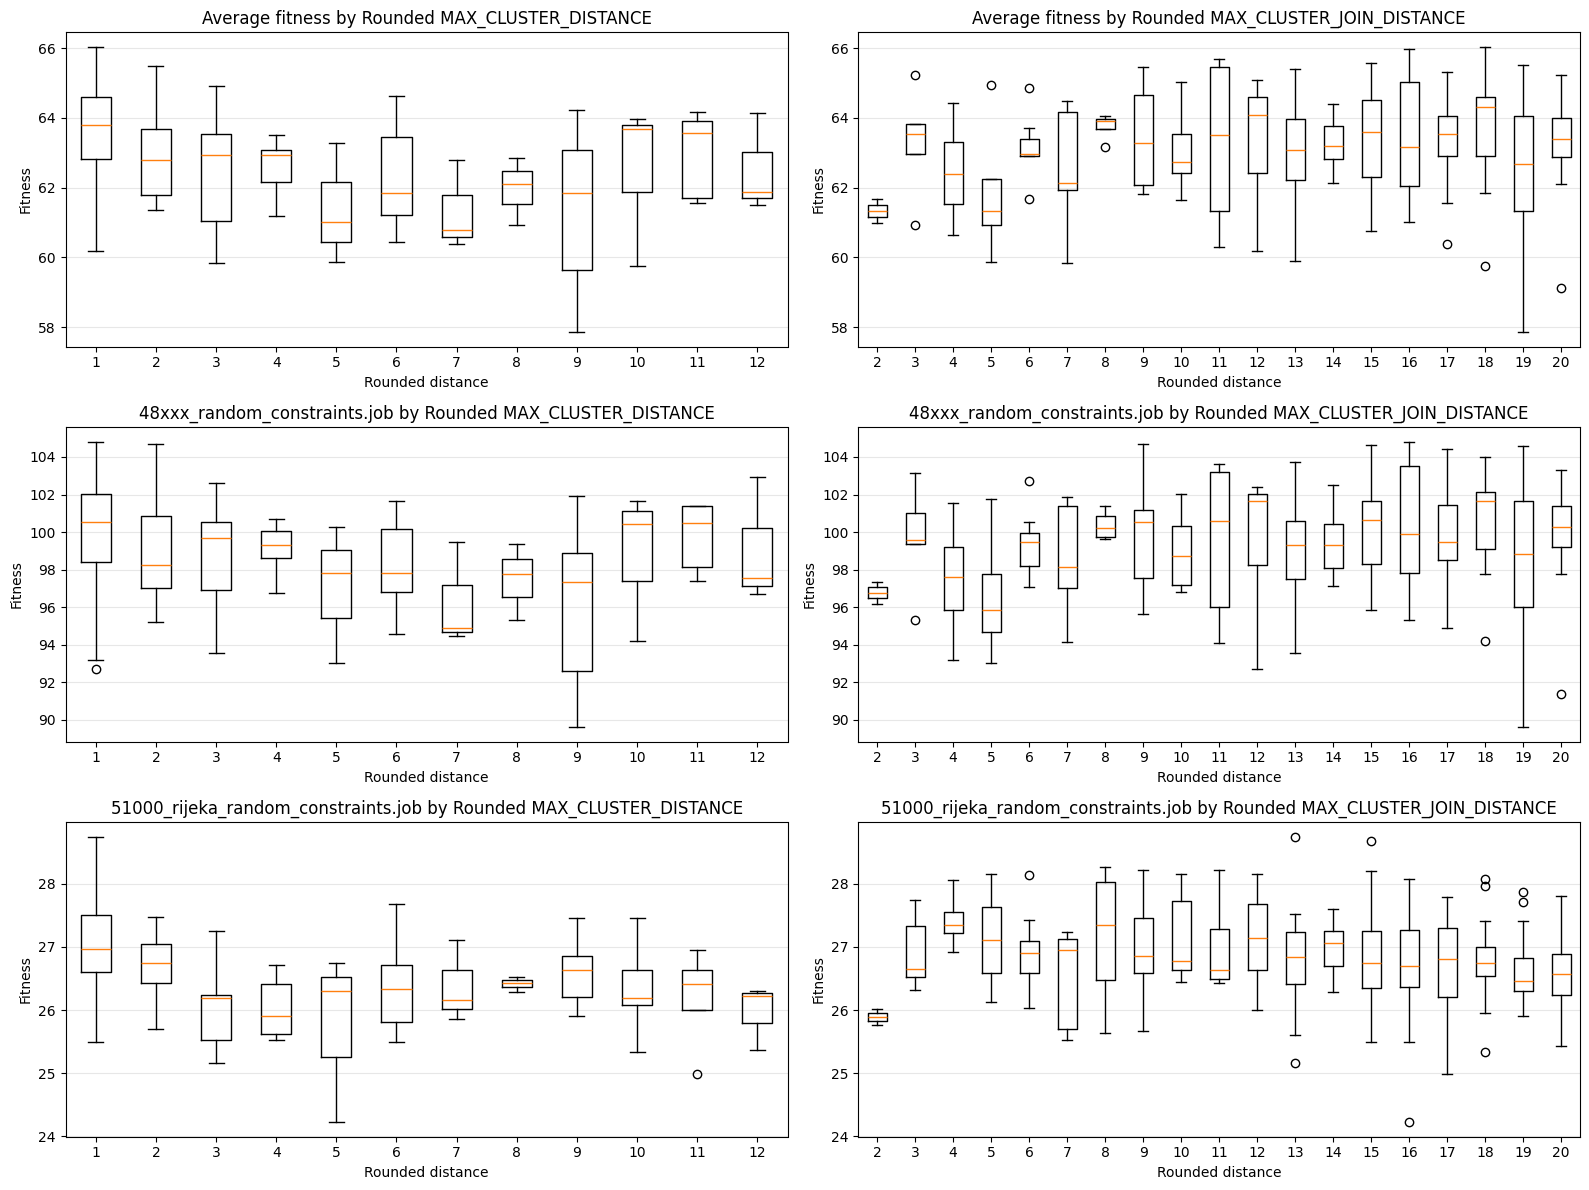

In [31]:
def plot_fitness_by_rounded_distance(ax, distance_col, target_fitness_col, title):
    plot_df = df[[distance_col, target_fitness_col]].dropna().copy()
    plot_df['rounded_distance'] = plot_df[distance_col].round().astype(int)
    order = sorted(plot_df['rounded_distance'].unique())
    data = [
        plot_df.loc[plot_df['rounded_distance'] == value, target_fitness_col]
        for value in order
    ]

    ax.boxplot(data, labels=order)
    ax.set_xlabel('Rounded distance')
    ax.set_ylabel('Fitness')
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)

cluster_settings = [
    ('general_MAX_CLUSTER_DISTANCE', 'MAX_CLUSTER_DISTANCE'),
    ('general_MAX_CLUSTER_JOIN_DISTANCE', 'MAX_CLUSTER_JOIN_DISTANCE'),
]

cluster_fitness_cols = [fitness_col, *fitness_cols]
fig, axes = plt.subplots(
    len(cluster_fitness_cols),
    len(cluster_settings),
    figsize=(16, 4 * len(cluster_fitness_cols)),
)

if len(cluster_fitness_cols) == 1:
    axes = [axes]

for row_axes, target_fitness_col in zip(axes, cluster_fitness_cols):
    fitness_label = fitness_labels.get(target_fitness_col, target_fitness_col)
    for ax, (distance_col, distance_label) in zip(row_axes, cluster_settings):
        plot_fitness_by_rounded_distance(
            ax,
            distance_col,
            target_fitness_col,
            f'{fitness_label} by Rounded {distance_label}',
        )

plt.tight_layout()
plt.show()


d:\Coding\FAKS\Mentor\working-sundays\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Average fitness: RandomForest surrogate train R2 = 0.684 (201 rows)


,mean_abs_shap
general_MAX_CLUSTER_DISTANCE,0.456248
crossover_child2_geoP,0.100745
mutator_child2_weight,0.081767
mutator_child2_p,0.063702
eliminator_p,0.050697
mutator_average_num_mutations,0.047211
general_MAX_CLUSTER_JOIN_DISTANCE,0.043546
crossover_comp_p,0.035476
eliminator_elitism,0.034787
crossover_expected_column_switch_pressure,0.027592


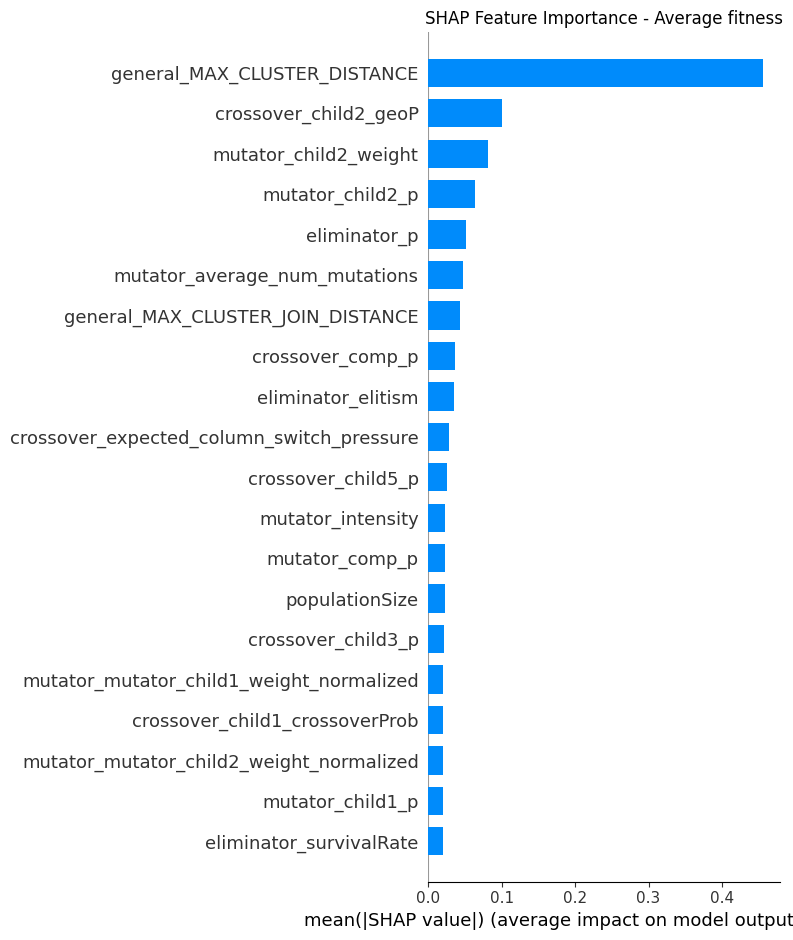

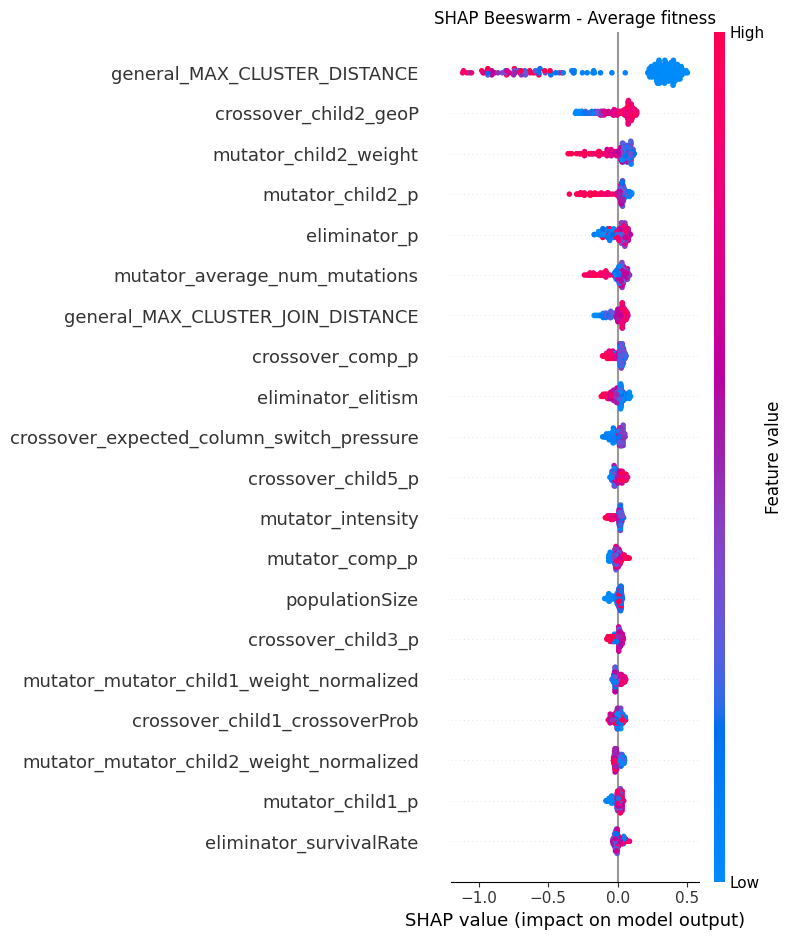

48xxx_random_constraints.job: RandomForest surrogate train R2 = 0.662 (201 rows)


,mean_abs_shap
general_MAX_CLUSTER_DISTANCE,0.400655
crossover_child2_geoP,0.197117
mutator_child2_p,0.149574
eliminator_p,0.121551
mutator_child2_weight,0.120140
general_MAX_CLUSTER_JOIN_DISTANCE,0.109919
mutator_mutator_child1_weight_normalized,0.102247
mutator_mutator_child2_weight_normalized,0.096699
populationSize,0.086961
crossover_comp_p,0.081643


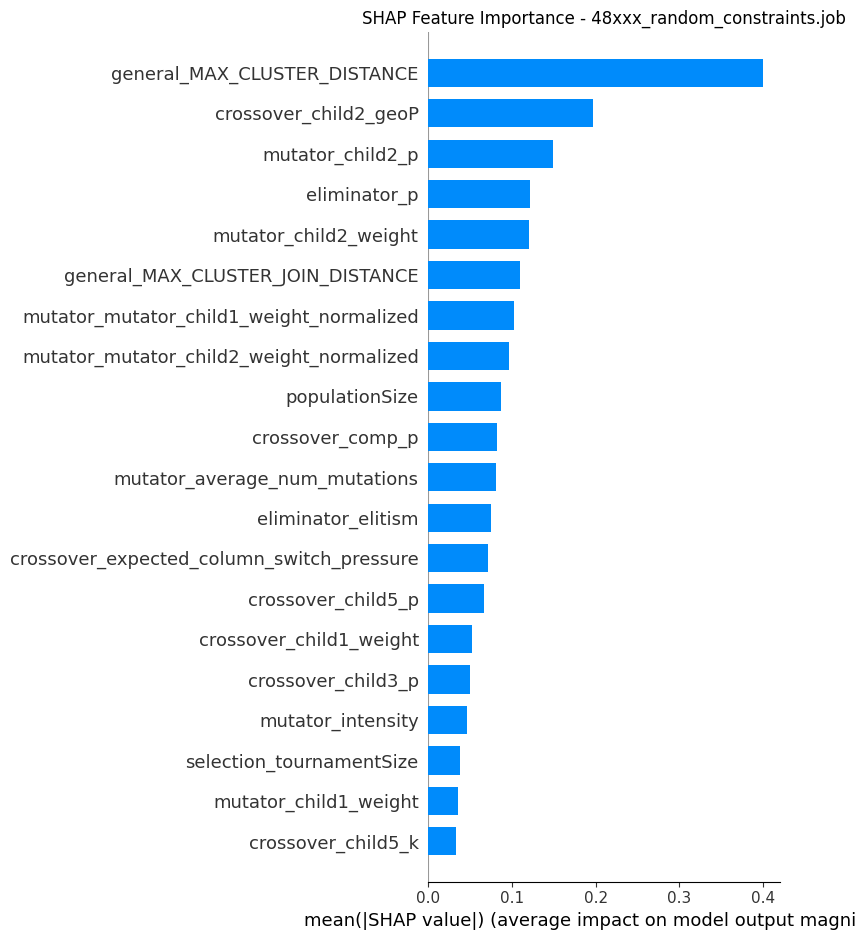

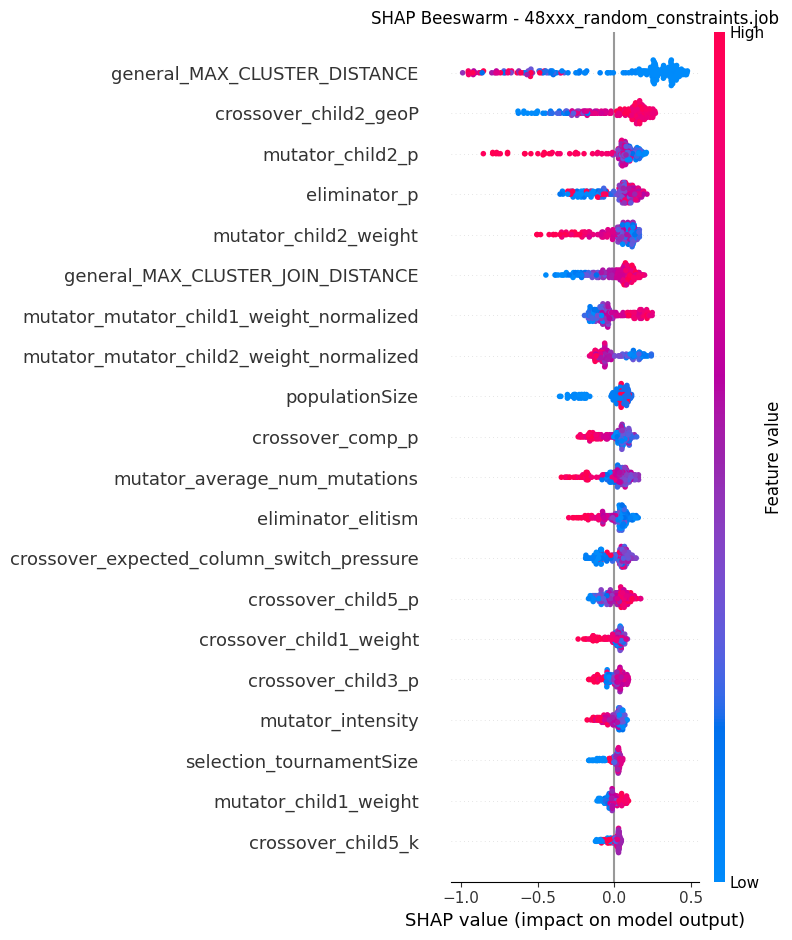

51000_rijeka_random_constraints.job: RandomForest surrogate train R2 = 0.710 (201 rows)


,mean_abs_shap
general_MAX_CLUSTER_DISTANCE,0.322211
crossover_child2_geoP,0.028343
crossover_child2_crossoverProb,0.022859
crossover_expected_column_switch_pressure,0.019109
crossover_child1_geoP,0.018398
mutator_intensity,0.018308
eliminator_p,0.016860
crossover_child2_weight,0.015260
general_MAX_CLUSTER_JOIN_DISTANCE,0.015203
crossover_child1_crossoverProb,0.015052


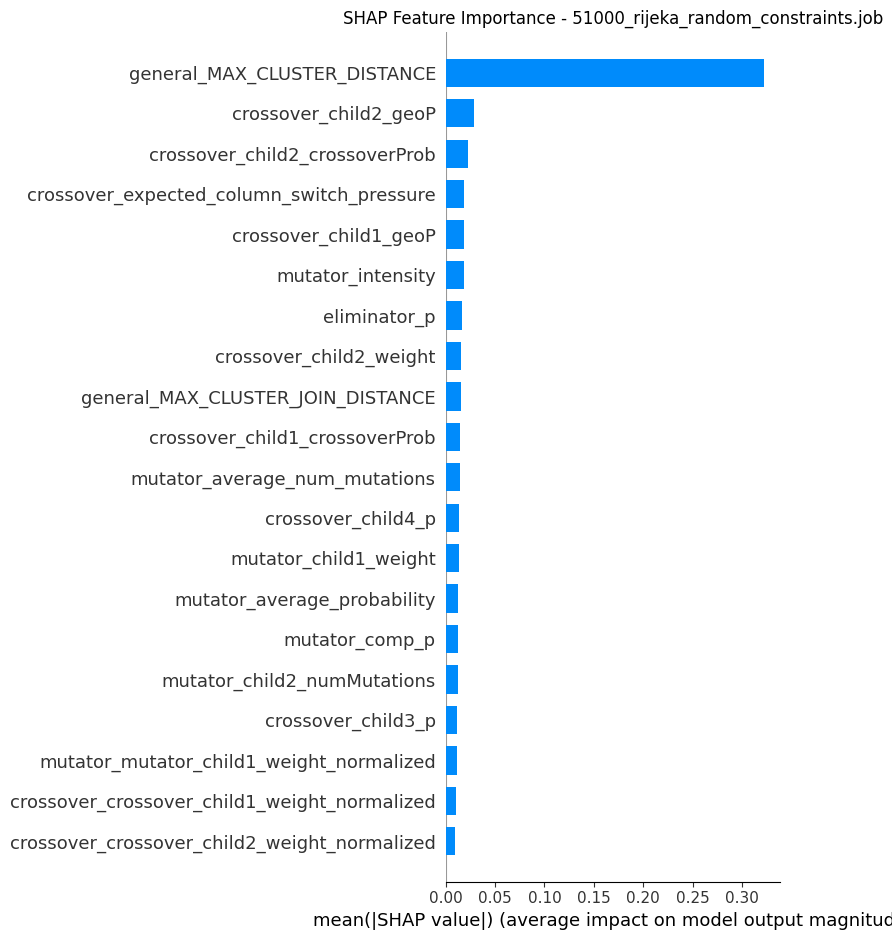

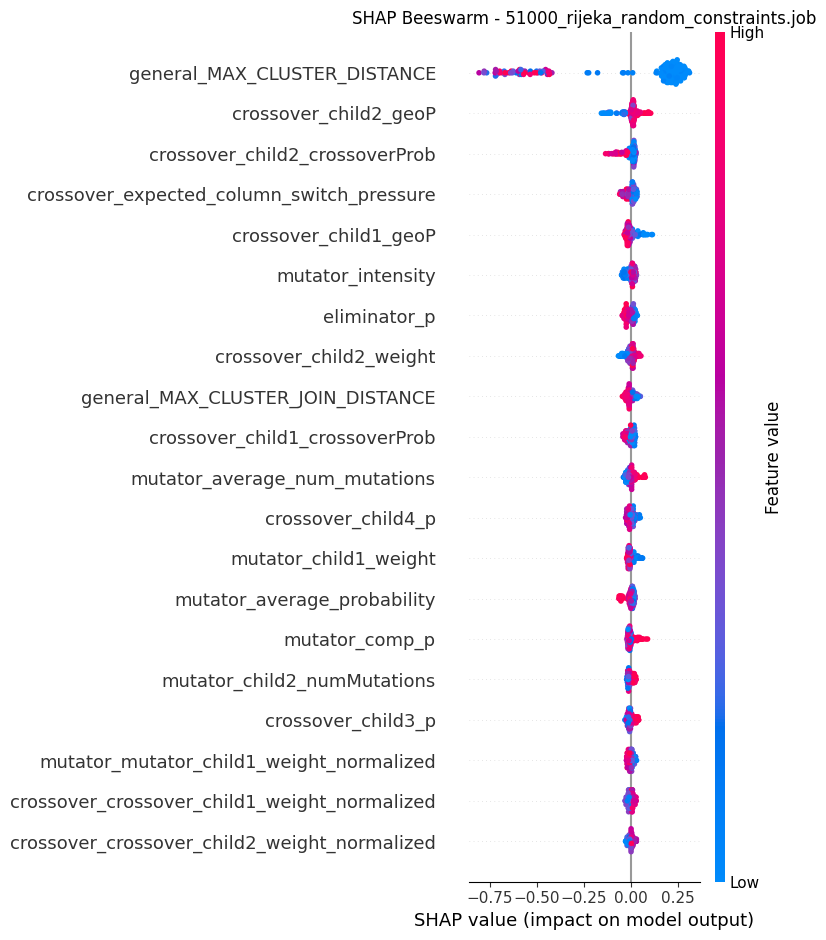

In [32]:
import shap

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


def add_normalized_weight_features(model_df, weight_cols, prefix):
    existing_weight_cols = [col for col in weight_cols if col in model_df.columns]
    if not existing_weight_cols:
        return

    weight_sum = model_df[existing_weight_cols].sum(axis=1).replace(0, pd.NA)
    for col in existing_weight_cols:
        normalized_col = f'{prefix}_{col}_normalized'
        model_df[normalized_col] = model_df[col] / weight_sum


model_df = df.copy()

mutator_weight_cols = ['mutator_child1_weight', 'mutator_child2_weight']
crossover_weight_cols = [f'crossover_child{i}_weight' for i in range(1, 6)]
add_normalized_weight_features(model_df, mutator_weight_cols, 'mutator')
add_normalized_weight_features(model_df, crossover_weight_cols, 'crossover')

if all(col in model_df.columns for col in mutator_weight_cols):
    mutator_weight_sum = model_df[mutator_weight_cols].sum(axis=1).replace(0, pd.NA)
    mutator_child1_share = model_df['mutator_child1_weight'] / mutator_weight_sum
    mutator_child2_share = model_df['mutator_child2_weight'] / mutator_weight_sum
    model_df['mutator_average_num_mutations'] = (
        model_df['mutator_child1_numMutations'] * mutator_child1_share
        + model_df['mutator_child2_numMutations'] * mutator_child2_share
    )
    model_df['mutator_average_probability'] = (
        model_df['mutator_child1_p'] * mutator_child1_share
        + model_df['mutator_child2_p'] * mutator_child2_share
    )
    model_df['mutator_intensity'] = (
        model_df['mutator_average_num_mutations']
        * model_df['mutator_average_probability']
    )

if all(col in model_df.columns for col in crossover_weight_cols):
    crossover_weight_sum = model_df[crossover_weight_cols].sum(axis=1).replace(0, pd.NA)
    crossover_shares = {
        i: model_df[f'crossover_child{i}_weight'] / crossover_weight_sum
        for i in range(1, 6)
    }
    model_df['crossover_expected_column_switch_pressure'] = (
        crossover_shares[1]
        * (1 / model_df['crossover_child1_geoP'])
        * model_df['crossover_child1_crossoverProb']
        + crossover_shares[5]
        * model_df['crossover_child5_k']
        * model_df['crossover_child5_p']
    )
    model_df['crossover_expected_row_switch_pressure'] = (
        crossover_shares[2]
        * (1 / model_df['crossover_child2_geoP'])
        * model_df['crossover_child2_crossoverProb']
        + crossover_shares[4]
        * model_df['crossover_child4_k']
        * model_df['crossover_child4_p']
    )
    model_df['crossover_single_point_pressure'] = (
        crossover_shares[3] * model_df['crossover_child3_p']
    )

target_cols = [fitness_col, *fitness_cols]
excluded_cols = {'iteration', 'timestamp', *target_cols}
feature_cols = [
    col for col in model_df.columns
    if col not in excluded_cols and not col.endswith('_fitness')
]

X_raw = model_df[feature_cols].copy()
X = pd.get_dummies(X_raw, drop_first=False)
X = X.apply(pd.to_numeric, errors='coerce')

for target_col in target_cols:
    target_label = fitness_labels.get(target_col, target_col)
    analysis_df = pd.concat([X, model_df[target_col]], axis=1).dropna()
    if len(analysis_df) < 10:
        print(f'Skipping {target_label}: only {len(analysis_df)} complete rows')
        continue

    X_target = analysis_df.drop(columns=[target_col])
    y_target = analysis_df[target_col]

    model = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=max(1, min(5, len(analysis_df) // 20)),
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_target, y_target)

    predictions = model.predict(X_target)
    train_r2 = r2_score(y_target, predictions)
    print(f'{target_label}: RandomForest surrogate train R2 = {train_r2:.3f} ({len(analysis_df)} rows)')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_target)

    mean_abs_shap = pd.Series(
        abs(shap_values).mean(axis=0),
        index=X_target.columns,
    ).sort_values(ascending=False)
    display(mean_abs_shap.head(20).to_frame('mean_abs_shap'))

    shap.summary_plot(
        shap_values,
        X_target,
        plot_type='bar',
        max_display=20,
        show=False,
    )
    plt.title(f'SHAP Feature Importance - {target_label}')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(
        shap_values,
        X_target,
        max_display=20,
        show=False,
    )
    plt.title(f'SHAP Beeswarm - {target_label}')
    plt.tight_layout()
    plt.show()


In [41]:
best_target_col = 'avg_fitness'
best_row = df.loc[df[best_target_col].idxmax()]

best_score_cols = [
    'iteration',
    'timestamp',
    best_target_col,
    *fitness_cols,
]
best_score_cols = [col for col in best_score_cols if col in df.columns]

parameter_cols = [
    col for col in df.columns
    if col not in {'iteration', 'timestamp', best_target_col, *fitness_cols}
]

best_scores = best_row[best_score_cols].to_frame(name='value')
best_parameters = best_row[parameter_cols].to_frame(name='value')

print(f'Best run by {best_target_col}: iteration {int(best_row["iteration"])}')
display(best_scores)
print('Best run parameters')
display(best_parameters)


Best run by avg_fitness: iteration 53


,value
iteration,53
timestamp,NaT
avg_fitness,66.04445
48xxx_random_constraints.job_fitness,104.01698
51000_rijeka_random_constraints.job_fitness,28.071921


Best run parameters


,value
general_MAX_CLUSTER_DISTANCE,1.0
general_MAX_CLUSTER_JOIN_DISTANCE,18.112532
populationSize,500
generations,2000
newChromosomes,12
eliminator_type,EliteGeometricEliminator
eliminator_elitism,4
eliminator_survivalRate,0.128116
eliminator_p,0.1
mutator_comp_p,0.999996
